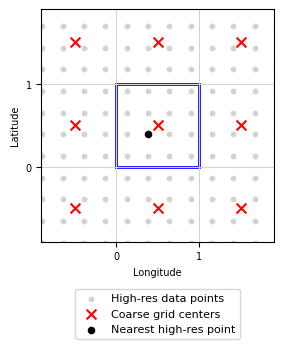

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from utils.plot_style import set_style
set_style()   # apply once

fig, ax = plt.subplots(figsize=(3, 5))

# Original "high-res" grid (schematic: 0.25° resolution for clarity)
orig_lons = np.linspace(-5, 5, 40)
orig_lats = np.linspace(-3, 3, 24)
orig_lon_grid, orig_lat_grid = np.meshgrid(orig_lons, orig_lats)

# Plot high-resolution points
ax.scatter(orig_lon_grid, orig_lat_grid, s=10, c="lightgray", label="High-res data points")

# Coarse grid centers (1° x 1° cells)
coarse_lons = np.arange(-1.5, 2.5, 1)
coarse_lats = np.arange(-1.5, 2.5, 1)
coarse_lon_grid, coarse_lat_grid = np.meshgrid(coarse_lons, coarse_lats)

# Plot coarse grid centers
ax.scatter(coarse_lon_grid, coarse_lat_grid, s=50, c="red", marker="x", label="Coarse grid centers")

ax.set_xticks(np.arange(-2, 3, 1))
ax.set_yticks(np.arange(-2, 3, 1))

ax.grid(True, which="both", color="lightgrey", linewidth=0.8)

# Example: highlight one coarse cell (1° × 1° box)
highlight_cell = (0.5, 0.5)  # center (lat, lon)
cell_size = 1
rect = plt.Rectangle((highlight_cell[1] - cell_size/2, highlight_cell[0] - cell_size/2),
                     cell_size, cell_size, fill=False, edgecolor="blue", linewidth=2)

# Find nearest original point to the highlight cell center
distances = (orig_lon_grid - highlight_cell[1])**2 + (orig_lat_grid - highlight_cell[0])**2
min_idx = np.unravel_index(np.argmin(distances), distances.shape)
nearest_point = (orig_lon_grid[min_idx], orig_lat_grid[min_idx])

# Mark nearest high-res point
ax.scatter(*nearest_point, s=20, c="black", marker="o", label="Nearest high-res point")

# Labels, ticks, and legend
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
# ax.set_title("Regridding: Nearest High-Res Point for 1° x 1° Cell")
# ax.legend(loc="upper right")


ax.set_xlim(-0.9, 1.9)
ax.set_ylim(-0.9, 1.9)
ax.set_aspect('equal', adjustable='box')
ax.add_patch(rect)

legend = ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),   # push below plot
    ncol=1,                       # place items in one row
    frameon=True ,                # cleaner look (optional)
    fontsize=8   
)

path = '../../outputs/plots/gridding/grid_plot.png'
plt.savefig(path, format='png', dpi=400, bbox_inches='tight')
plt.show()